# Optical Neural Network (ONN) on MNIST — Phase-Mask Classifier

This is a **standalone advanced notebook**. It trains a small diffractive optical network to classify
MNIST digits using alternating phase masks and free-space propagation layers, with the final intensity
sampled by a `2x5` detector grid whose 10 outputs serve as class logits.

## Modeling assumptions

- grayscale MNIST images are injected as field amplitudes on the input plane,
- each trainable layer is phase-only, with propagation between layers fixed by the chosen spacing, and
- the final detector array is treated as a task-specific readout rather than a physically calibrated camera.

This example is best read as a compact differentiable-optics classifier demo, not as a benchmark for
state-of-the-art digit recognition.


## 0  Imports

We use JAX and Optax for training, Matplotlib for visual diagnostics, and `fouriax` optics modules for
the phase-mask stack, intermediate intensity monitors, and detector-array readout.


In [1]:
from __future__ import annotations

import argparse
import urllib.request
from pathlib import Path

import jax
import jax.image
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from matplotlib.patches import Rectangle

import fouriax as fx

import os
from pathlib import Path as _Path
%matplotlib inline

REPO_ROOT = fx.utils.find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


try:
    EXAMPLES_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    EXAMPLES_ROOT = fx.utils.find_repo_root(Path.cwd()) / "examples"
EXAMPLES_DATA_DIR = EXAMPLES_ROOT / "data"
EXAMPLES_ARTIFACTS_DIR = EXAMPLES_ROOT / "artifacts"


## 1  Paths and Parameters

The parameters control both the learning problem and the optical architecture: device selection,
dataset size, number of phase layers, phase-mask downsampling, propagation distance, and optimization
hyperparameters.


In [2]:
# Keep the MNIST cache under examples/data by default.
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
DATA_PATH = Path(str(EXAMPLES_DATA_DIR / 'mnist.npz'))
ARTIFACTS_DIR = Path(str(EXAMPLES_ARTIFACTS_DIR))
PLOT_PATH = ARTIFACTS_DIR / "onn_mnist_field_evolution.png"
SUMMARY_PATH = ARTIFACTS_DIR / "onn_mnist_summary.json"

DEVICE = 'cpu'
SEED = 0
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.05
NUM_PHASE_LAYERS = 4
PHASE_MASK_DOWNSAMPLE = 4
NYQUIST_FACTOR = 1.0
DISTANCE_UM = 50.0
TRAIN_SAMPLES = 1000
TEST_SAMPLES = 100
PLOT = True


## 2  Helper Functions

The helpers load and cache MNIST, then resize the digit images onto the optical working grid. This
keeps the rest of the notebook focused on the optical model and training loop rather than on dataset
plumbing.


In [3]:
def load_mnist(cache_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if not cache_path.exists():
        print(f"Downloading MNIST to {cache_path} ...")
        urllib.request.urlretrieve(MNIST_URL, cache_path)

    with np.load(cache_path) as data:
        x_train = data["x_train"].astype(np.float32) / 255.0
        y_train = data["y_train"].astype(np.int32)
        x_test = data["x_test"].astype(np.float32) / 255.0
        y_test = data["y_test"].astype(np.int32)
    return x_train, y_train, x_test, y_test


def resize_images_to_grid(images: np.ndarray, grid: fx.Grid) -> np.ndarray:
    arr = jnp.asarray(images, dtype=jnp.float32)[..., None]
    resized = jax.image.resize(
        arr,
        shape=(arr.shape[0], grid.ny, grid.nx, 1),
        method="linear",
    )[..., 0]
    return np.asarray(resized, dtype=np.float32)


## 3  Setup

We choose a working grid, build a repeated block of

$$
\text{phase mask} \;\rightarrow\; \text{propagation},
$$

and attach `IntensityMonitor` layers so the field evolution can be visualized after training. The
final `DetectorArray` has 10 cells arranged as `2×5`, one for each digit class.

The trainable parameters live on a lower-resolution latent grid and are bilinearly upsampled before
being converted into physical phase masks.


In [4]:
jax.config.update("jax_platform_name", DEVICE)
selected_device = jax.devices()[0]
jax.config.update("jax_default_device", selected_device)
print(
    "device="
    f"{selected_device.platform} kind={getattr(selected_device, 'device_kind', 'unknown')}"
)

input_grid = fx.Grid.from_extent(nx=28, ny=28, dx_um=1.0, dy_um=1.0)
spectrum = fx.Spectrum.from_scalar(1.55)
propagator = fx.plan_propagation(
    mode="auto",
    grid=input_grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
    nyquist_factor=NYQUIST_FACTOR,
    min_padding_factor=2.0,
)
work_grid = propagator.precomputed_grid or input_grid
mask_nx = work_grid.nx // PHASE_MASK_DOWNSAMPLE
mask_ny = work_grid.ny // PHASE_MASK_DOWNSAMPLE
mask_grid = fx.Grid.from_extent(
    nx=mask_nx,
    ny=mask_ny,
    dx_um=(work_grid.nx * work_grid.dx_um) / mask_nx,
    dy_um=(work_grid.ny * work_grid.dy_um) / mask_ny,
)
detector_grid = fx.Grid.from_extent(
    nx=5,
    ny=2,
    dx_um=(work_grid.nx * work_grid.dx_um) / 5.0,
    dy_um=(work_grid.ny * work_grid.dy_um) / 2.0,
)
detector_array = fx.DetectorArray(
    detector_grid=detector_grid,
)

def build_module(raw_params: jnp.ndarray) -> fx.OpticalModule:
    layers = [fx.IntensityMonitor(sum_wavelengths=True, output_domain="spatial")]
    for i in range(raw_params.shape[0]):
        upsampled_latent = jax.image.resize(
            raw_params[i],
            shape=(work_grid.ny, work_grid.nx),
            method="linear",
        )
        bounded_phase = 2.0 * jnp.pi * jax.nn.sigmoid(upsampled_latent)
        layers.append(fx.PhaseMask(phase_map_rad=bounded_phase))
        layers.append(propagator)
        layers.append(fx.IntensityMonitor(sum_wavelengths=True, output_domain="spatial"))
    return fx.OpticalModule(layers=tuple(layers), sensor=detector_array)

x_train, y_train, x_test, y_test = load_mnist(DATA_PATH)
x_train = x_train[:TRAIN_SAMPLES]
y_train = y_train[:TRAIN_SAMPLES]
x_test = x_test[:TEST_SAMPLES]
y_test = y_test[:TEST_SAMPLES]
x_train = resize_images_to_grid(x_train, work_grid)
x_test = resize_images_to_grid(x_test, work_grid)

key = jax.random.PRNGKey(SEED)
phase_params = 0.05 * jax.random.normal(
    key,
    (NUM_PHASE_LAYERS, mask_grid.ny, mask_grid.nx),
    dtype=jnp.float32,
)


device=cpu kind=cpu


W0314 19:56:40.195447   46120 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 4  Loss Function and Optimization

The forward pass maps each input image to detector intensities, reshapes them into 10 logits, and
optimizes the negative log-likelihood of the correct class. If $z_{n,c}$ is the detector logit for
sample $n$ and class $c$, then the softmax probability is

$$
p_{n,c} = \frac{e^{z_{n,c}}}{\sum_{k=1}^{10} e^{z_{n,k}}},
$$

and the minibatch classification loss is

$$
\mathcal{L}_{\mathrm{cls}} = -\frac{1}{B} \sum_{n=1}^{B} \log p_{n,y_n},
$$

where $y_n$ is the ground-truth digit label. Accuracy is evaluated with the same optical model,
without adding a separate electronic classifier head.

This makes the task interpretation very direct: the diffractive stack itself is learning to route
optical energy toward the detector region associated with the correct class.


In [5]:
def logits_batch(raw_params: jnp.ndarray, images_3d: jnp.ndarray) -> jnp.ndarray:
    module = build_module(raw_params)
    field = fx.Field(
        data=images_3d[:, None, :, :].astype(jnp.complex64),
        grid=work_grid,
        spectrum=spectrum,
    )
    return module.measure(field).reshape((images_3d.shape[0], -1))

def batch_loss_fn(
    params: jnp.ndarray,
    batch: tuple[np.ndarray, np.ndarray] | tuple[jnp.ndarray, jnp.ndarray],
) -> jnp.ndarray:
    image_raw, label_raw = batch
    images = jnp.asarray(image_raw, dtype=jnp.float32)
    labels = jnp.asarray(label_raw, dtype=jnp.int32)
    logits = logits_batch(params, images)
    log_probs = logits - jax.scipy.special.logsumexp(logits, axis=-1, keepdims=True)
    return -jnp.mean(log_probs[jnp.arange(labels.shape[0]), labels])

def batch_accuracy(params: jnp.ndarray, images: np.ndarray, labels: np.ndarray) -> float:
    logits = np.asarray(logits_batch(params, jnp.asarray(images)))
    pred = np.argmax(logits, axis=1)
    return float(np.mean(pred == labels))

optimizer = optax.adam(learning_rate=LEARNING_RATE)
train_data = (x_train, y_train)
val_data = (x_test, y_test)

result = fx.optim.optimize_dataset_optical_module(
    init_params=phase_params,
    build_module=build_module,
    batch_loss_fn=batch_loss_fn,
    optimizer=optimizer,
    train_data=train_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    val_data=val_data,
    seed=SEED + 1,
)


epoch=001/010 batches=16 elapsed=0.00s


  batch=001/016 train_loss=208.908386 batch_time=0.33s elapsed=0.40s


  batch=002/016 train_loss=136.204529 batch_time=0.00s elapsed=0.62s


  batch=003/016 train_loss=140.094940 batch_time=0.00s elapsed=0.85s


  batch=004/016 train_loss=126.033264 batch_time=0.00s elapsed=1.07s


...

  batch=012/016 train_loss=1.364487 batch_time=0.00s elapsed=38.36s


  batch=013/016 train_loss=0.475452 batch_time=0.00s elapsed=38.59s


  batch=014/016 train_loss=0.566105 batch_time=0.00s elapsed=38.81s


  batch=015/016 train_loss=1.238790 batch_time=0.00s elapsed=39.03s
  batch=016/016 train_loss=0.005544 batch_time=0.00s elapsed=39.17s


->epoch=010/010 val_loss=2.186733 train_loss=0.005544 epoch_time=3.76s elapsed=39.38s [best]


## 5  Evaluation

After training, we report train/test accuracy and inspect one sample digit by observing the monitored
intensity checkpoints through the best optical module. This ties the classification result back to a
physical picture of how the field evolves across the diffractive layers.


In [6]:
train_acc = batch_accuracy(result.params_result.best_params, x_train, y_train)
test_acc = batch_accuracy(result.params_result.best_params, x_test, y_test)
final_val_loss = (
    float(result.params_result.final_val_metrics["val_loss"])
    if result.params_result.final_val_metrics
    else float("nan")
)
print(
    f"final_train_acc={train_acc:.4f} final_test_acc={test_acc:.4f} "
    f"final_val_loss={final_val_loss:.4f}"
)

module = result.best_module
sample_idx = 0
test_image = jnp.asarray(x_test[sample_idx], dtype=jnp.float32)
sample_field = fx.Field(
    data=test_image[None, :, :].astype(jnp.complex64),
    grid=work_grid,
    spectrum=spectrum,
)


final_train_acc=0.9170 final_test_acc=0.8300 final_val_loss=2.1867


## 6  Plot Results

The top row visualizes the propagated intensity after each stage, while the bottom row shows the
learned phase masks. The final panel overlays the detector regions used as class readouts.

A useful read of this figure is architectural rather than aesthetic: it shows whether the network has
learned progressively structured energy routing that culminates in a separable detector response.


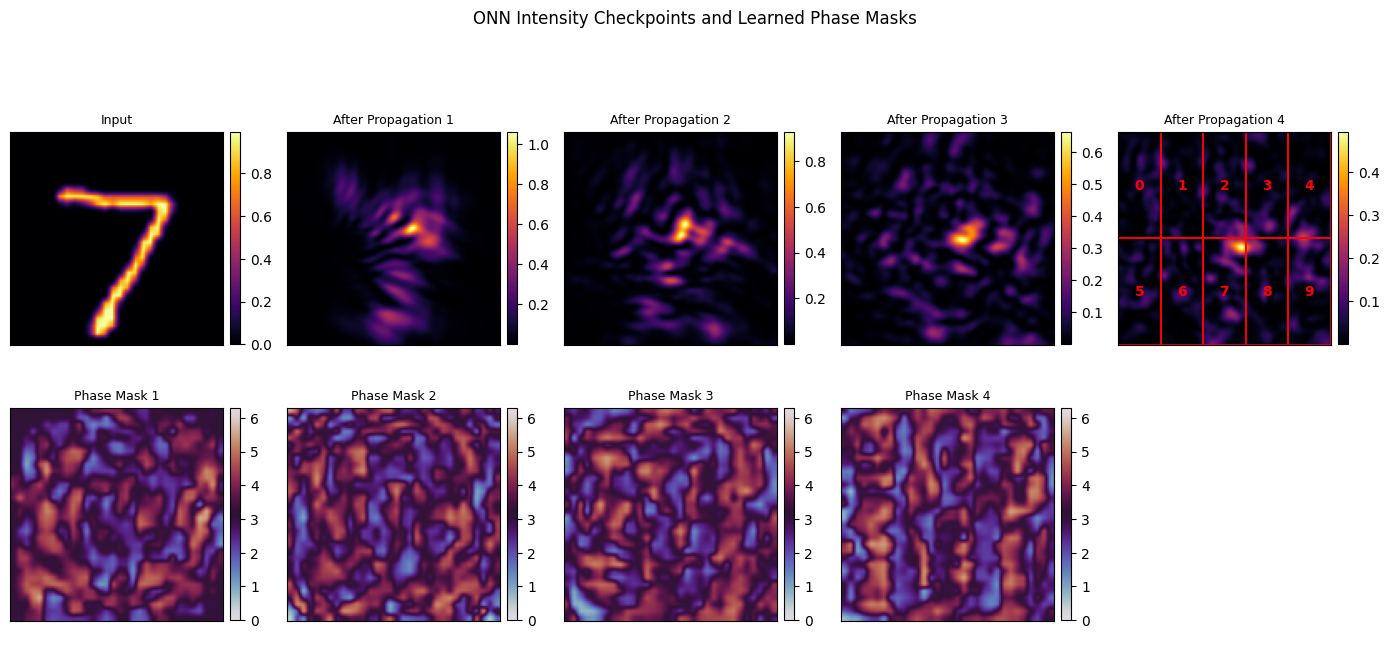

saved: /Users/liam/metasurface/fouriax/examples/artifacts/onn_mnist_field_evolution.png


In [7]:
if PLOT:
    _, intensity_steps = module.observe(sample_field)
    phase_masks = [
        np.asarray(stage.phase_map_rad)
        for stage in module.layers
        if isinstance(stage, fx.PhaseMask)
    ]
    titles = ["Input"] + [f"After Propagation {i + 1}" for i in range(len(intensity_steps) - 1)]
    n_cols = max(len(intensity_steps), len(phase_masks))
    fig_field, axes = plt.subplots(
        2,
        n_cols,
        figsize=(max(6.0, 2.8 * n_cols), 6.8),
        squeeze=False,
    )
    for col, ax in enumerate(axes[0]):
        if col >= len(intensity_steps):
            ax.axis("off")
            continue
        title = titles[col]
        image = intensity_steps[col]
        im = ax.imshow(np.asarray(image), cmap="inferno")
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig_field.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        if col == len(intensity_steps) - 1:
            cell_w = work_grid.nx / detector_grid.nx
            cell_h = work_grid.ny / detector_grid.ny
            digit = 0
            for row in range(detector_grid.ny):
                for det_col in range(detector_grid.nx):
                    ax.add_patch(
                        Rectangle(
                            (det_col * cell_w - 0.5, row * cell_h - 0.5),
                            cell_w,
                            cell_h,
                            fill=False,
                            edgecolor="red",
                            linewidth=1.2,
                        )
                    )
                    ax.text(
                        det_col * cell_w + 0.5 * cell_w - 0.5,
                        row * cell_h + 0.5 * cell_h - 0.5,
                        str(digit),
                        color="red",
                        fontsize=10,
                        fontweight="bold",
                        ha="center",
                        va="center",
                    )
                    digit += 1

    for col, ax in enumerate(axes[1]):
        if col >= len(phase_masks):
            ax.axis("off")
            continue
        phase = phase_masks[col]
        im = ax.imshow(phase, cmap="twilight", vmin=0.0, vmax=2.0 * np.pi)
        ax.set_title(f"Phase Mask {col + 1}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig_field.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

    fig_field.suptitle("ONN Intensity Checkpoints and Learned Phase Masks", y=0.98)
    fig_field.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
    fig_field.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
